In [ ]:
import torch
from transformers import AutoModelForCausalLM
import dct
import dashboard

model = AutoModelForCausalLM.from_pretrained("meta-llama/Llama-3.2-3B-Instruct")

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

In [ ]:
input_scale = 2.513812184333722
source_layer = 10
fwd_batch_size = 1

In [ ]:
slice_to_end = dct.SlicedModel(
    model,
    start_layer=source_layer,
    end_layer=model.config.num_hidden_layers,
    layers_name="model.layers",
    apply_final_norm=True,
)
delta_acts_end_single = dct.DeltaActivations(slice_to_end)

Y_end = torch.zeros_like(Y)
with torch.no_grad():
    for b in range(0, X.shape[0], fwd_batch_size):
        Y_end[b:b+fwd_batch_size] = slice_to_end(X[b:b+fwd_batch_size])

REFUSAL_TOKEN = tokenizer.encode("I", add_special_tokens=False)[0]
SURE_TOKEN = tokenizer.encode("Sure", add_special_tokens=False)[0]
with torch.no_grad():
    target_vec = model.lm_head.weight.data[SURE_TOKEN,:] - model.lm_head.weight.data[REFUSAL_TOKEN,:]

scores, indices = dct_.rank(delta_acts_end_single, X, Y_end, target_vec=target_vec,
                            batch_size=fwd_batch_size, factor_batch_size=factor_batch_size)

In [ ]:
U, V = torch.load("U_llama_50.pt"), torch.load("V_llama_50.pt")

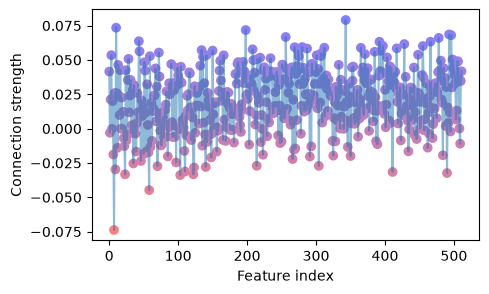

In [2]:
dashboard.display_pullback_features(U, V[:, 0])